## Problem 6.2 - Bias - Variance Decomposition - Ridge Regression

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [33]:
# define set-up
np.random.seed(42)
sigma = 0.1
degree = 5
n = 20 
n1 = 100
n2 = 500

lamdas = np.power(10,np.linspace(-5,1,100))
poly = PolynomialFeatures(degree = degree, include_bias = True)

theta_star = np.zeros(degree + 1)
theta_star[2] = 1  # coefficient for x^2 term

I = np.eye(degree + 1)

In [34]:
def f(x):
    return x**2

In [35]:
x_train = np.random.uniform(-1, 1, size = n)
phi = poly.fit_transform(x_train.reshape(-1,1))
sigma_hat = (1 / n) * phi.T @ phi

In [ ]:
avg_empirical_means = []
avg_empirical_std = []

for lam in lamdas:
    empirical_risks = []
    for _ in range(n1):
        y_train = f(x_train) + np.random.normal(0, sigma, size = n)
        model = Ridge(alpha = n * lam, fit_intercept = False)
        model.fit(phi, y_train)
        
        empirical_risks_n2 = []
        empirical_std_n2 = []
        for _ in range(n2):
            x_test = np.random.uniform(-1, 1, size = n)
            phi_test = poly.fit_transform(x_test.reshape(-1,1))
            y_test = f(x_test) + np.random.normal(0, sigma, size = n)
            y_pred = model.predict(phi_test)
            empirical_risks_n2.append(np.mean((y_test - y_pred)**2))

        empirical_risks.append(np.mean(empirical_risks_n2) - sigma**2)
    
    avg_empirical_means.append(np.mean(empirical_risks))
    avg_empirical_std.append(np.std(empirical_risks))

In [49]:
# computing theoretical values
theoretical_bias = []
theoretical_variance = []
theoretical_risks = []

for lam in lamdas:
    inverse_matrix = np.linalg.solve(sigma_hat + lam * I, np.eye(sigma_hat.shape[0]))
    theo_bias = (lam**2)* theta_star.T @ inverse_matrix @ inverse_matrix @ sigma_hat @ theta_star
    theo_variance = (sigma**2 / n) * np.trace(sigma_hat @ sigma_hat @ inverse_matrix @ inverse_matrix)
    theoretical_bias.append(theo_bias)
    theoretical_variance.append(theo_variance)
    theoretical_risks.append(theo_bias + theo_variance)

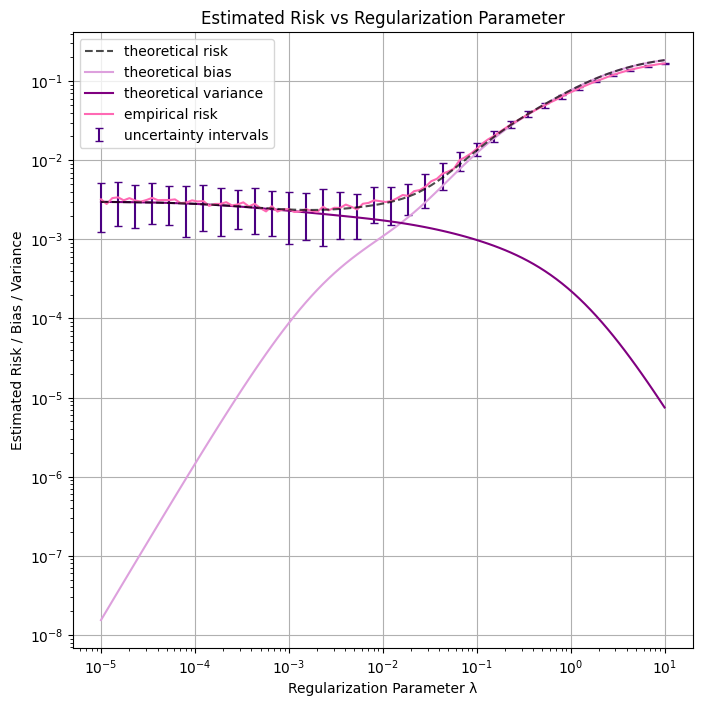

In [ ]:
# plot the results
plt.figure(figsize=(8,8))

plt.errorbar(lamdas[::3], np.array(avg_empirical_means)[::3], yerr = np.array(avg_empirical_std)[::3], fmt = 'none', color = 'indigo', label = 'uncertainty intervals', capsize = 3, capthick = 1)

plt.loglog(lamdas, theoretical_risks, linestyle = '--', color = 'black', label = 'theoretical risk', zorder = 4, alpha = 0.7)
plt.loglog(lamdas, theoretical_bias, color = 'plum', label = 'theoretical bias')
plt.loglog(lamdas, theoretical_variance, color = 'purple', label = 'theoretical variance')
plt.loglog(lamdas, avg_empirical_means, color = 'hotpink', label = 'empirical risk')
plt.xlabel('Regularization Parameter λ')
plt.ylabel('Estimated Risk / Bias / Variance')
plt.title('Estimated Risk vs Regularization Parameter')
plt.legend()
plt.grid(True)
plt.show() 

#### relation of bias/variance to approximation/estimation error and observations depending on lamda
The bias represents how far the prediction is from the underlying gorund truth function. High bias means that the model is too simple to recognize the structure of the ground truth. This relates to the approximation error, where for a small class of approximating functions the error is high, since the ground truth cannot be approximated well enough. 
In this example the bias is very small for a small regularization parameter lambda. Smaller lambda implies weaker regularization which yields a flexible model that can fit the gorund truth function better. This result corresponds to the result for our approximation error. 
  
The variance represents the flunctuation of the model's prediction. A high variance means that the model is very sensitive to the noise. This corresponds to the estimation error.  
In our example, the variance is decreasing with larger lambdas. The regularization of our model gets stronger and with that the sensitivity to noises decreases since we try to avoidd overfitting. This is the same result as we get for the estimation error.

Overall the bias and the variance strongly relate to the results we got earlier when considering approximation and estimation errors. For a weak regularization the training data is fitted better and therefore the approximation error and the bias are small. When we regulate the model more strongly, the model becomes less sensitive and we avoid overfitting, this results in a larger approx. error and bias but reduces the estimation error and the variance. 

